In [1]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


In [2]:
"""
CLIP Negation Weakness Reproduction
CLIP이 negation을 이해하지 못하는 현상을 재현하는 미니 실험.

핵심 가설:
    CLIP은 "a photo of a cat"과 "a photo of no cat"을 거의 구분하지 못한다.
    즉, 'no' / 'without' 같은 부정어를 사실상 무시한다.

연결 논문:
    Junsung Park et al., "Know 'No' Better: A Data-Driven Approach for
    Enhancing Negation Awareness in CLIP", ICCV 2025. (Vision & AI Lab, 고려대)

작성: [한지훈]
"""

import argparse
import numpy as np
import torch
import open_clip
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm


# 0. 설정

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "ViT-B-32"
PRETRAINED = "openai"


POS_TEMPLATE = "a photo of a {}"
NEG_TEMPLATES = [
    "a photo of no {}",
    "a photo with no {}",
    "a photo without a {}",
    "a photo that does not contain a {}",
]


In [3]:
# 1. 모델 / 데이터 로드
def load_model():
    model, _, preprocess = open_clip.create_model_and_transforms(
        MODEL_NAME, pretrained=PRETRAINED
    )
    tokenizer = open_clip.get_tokenizer(MODEL_NAME)
    model = model.to(DEVICE).eval()
    return model, preprocess, tokenizer


def load_dataset(preprocess, n_images=2000):
    ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=preprocess)
    classnames = ds.classes  # ['airplane', 'automobile', ...]
    # 너무 오래 걸리지 않도록 앞쪽 n_images만 사용 (재현엔 충분)
    if n_images and n_images < len(ds):
        ds = torch.utils.data.Subset(ds, range(n_images))
    loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=0)
    return loader, classnames


In [4]:
# 2. 텍스트/이미지 인코딩 유틸
@torch.no_grad()
def encode_texts(model, tokenizer, prompts):
    tokens = tokenizer(prompts).to(DEVICE)
    feats = model.encode_text(tokens)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats  # (num_prompts, dim)


@torch.no_grad()
def encode_all_images(model, loader):
    img_feats, labels = [], []
    for images, lbls in tqdm(loader, desc="이미지 인코딩"):
        images = images.to(DEVICE)
        feats = model.encode_image(images)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        img_feats.append(feats.cpu())
        labels.append(lbls)
    return torch.cat(img_feats), torch.cat(labels)

In [5]:
# 3. 실험
def build_class_prompts(classnames, template):
    return [template.format(c) for c in classnames]


@torch.no_grad()
def classify(img_feats, text_feats):
    """이미지 feature를 텍스트 프롬프트들에 대해 분류. argmax index 반환."""
    logits = img_feats.to(DEVICE) @ text_feats.T  # (N, num_classes)
    return logits.argmax(dim=1).cpu()


def run_experiments(model, tokenizer, img_feats, labels, classnames):
    results = {}

    # 실험 1: 표준 zero-shot baseline
    pos_prompts = build_class_prompts(classnames, POS_TEMPLATE)
    pos_text = encode_texts(model, tokenizer, pos_prompts)
    pos_pred = classify(img_feats, pos_text)
    pos_acc = (pos_pred == labels).float().mean().item()
    results["positive_accuracy"] = pos_acc
    print(f"\n[실험 1] 표준 zero-shot 정확도: {pos_acc*100:.1f}%")

    # 실험 2: 부정 프롬프트로 분류했을 때
    # '부정' 프롬프트로 분류해도 여전히 정답 클래스를 가리키면 CLIP이 'no'를 무시했다는 직접 증거
    print("\n[실험 2] 부정 프롬프트별 'negation-ignored rate'")
    print("  (정답 클래스를 부정했는데도 그 클래스가 1등으로 뽑힌 비율)")
    neg_ignored = {}
    for tmpl in NEG_TEMPLATES:
        neg_prompts = build_class_prompts(classnames, tmpl)
        neg_text = encode_texts(model, tokenizer, neg_prompts)
        neg_pred = classify(img_feats, neg_text)
        # 부정을 이해한다면 정답 클래스의 "no {c}" 점수는 '낮아야' 하므로
        # neg_pred == labels 가 적어야 정상. 높을수록 'no'를 무시한 것.
        ignored = (neg_pred == labels).float().mean().item()
        neg_ignored[tmpl] = ignored
        print(f"   - {tmpl:42s} : {ignored*100:5.1f}%")
    results["negation_ignored"] = neg_ignored

    # 실험 3: 같은 이미지에서 pos vs neg 유사도 직접 비교
    # "a photo of a {c}" 와 "a photo of no {c}" 의 코사인 유사도가 정답 이미지에서 얼마나 비슷한지 분포로 확인.
    print("\n[실험 3] 정답 이미지에서 긍정 vs 부정 프롬프트 유사도 비교")
    pos_text_full = encode_texts(model, tokenizer,
                                 build_class_prompts(classnames, POS_TEMPLATE))
    neg_text_full = encode_texts(model, tokenizer,
                                 build_class_prompts(classnames, NEG_TEMPLATES[0]))
    img_dev = img_feats.to(DEVICE)
    pos_sim_all = img_dev @ pos_text_full.T  # (N, C)
    neg_sim_all = img_dev @ neg_text_full.T  # (N, C)
    idx = torch.arange(len(labels))
    pos_sim_true = pos_sim_all[idx, labels].cpu().numpy()
    neg_sim_true = neg_sim_all[idx, labels].cpu().numpy()
    gap = float(np.mean(pos_sim_true - neg_sim_true))
    print(f"평균 유사도 차이 (긍정 - 부정): {gap:.4f}")
    print("0에 가까울수록 CLIP이 부정어를 무시한다는 뜻")
    results["pos_sim_true"] = pos_sim_true
    results["neg_sim_true"] = neg_sim_true
    results["sim_gap"] = gap

    return results

In [6]:
# 4. 시각화
def plot_results(results, classnames, out_prefix="result"):
    # (a) baseline vs negation-ignored
    fig, ax = plt.subplots(figsize=(7, 4))
    labels_bar = ["Positive\n(baseline)"] + [
        t.replace("a photo ", "").replace("{}", "X") for t in results["negation_ignored"]
    ]
    values = [results["positive_accuracy"]] + list(results["negation_ignored"].values())
    colors = ["#2a9d8f"] + ["#e76f51"] * len(results["negation_ignored"])
    ax.bar(range(len(values)), [v * 100 for v in values], color=colors)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels_bar, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("True class ranked #1 (%)")
    ax.set_title("CLIP keeps predicting the class even when it is negated")
    ax.axhline(100 / len(classnames), ls="--", c="gray",
               label=f"random ({100/len(classnames):.0f}%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_bar.png", dpi=150)
    print(f"saved: {out_prefix}_bar.png")

    # (b) pos vs neg 유사도 분포
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(results["pos_sim_true"], bins=40, alpha=0.6, label='"a photo of a X"', color="#2a9d8f")
    ax.hist(results["neg_sim_true"], bins=40, alpha=0.6, label='"a photo of no X"', color="#e76f51")
    ax.set_xlabel("Cosine similarity with true-class image")
    ax.set_ylabel("# images")
    ax.set_title(f"Positive vs negated prompt similarity (mean gap {results['sim_gap']:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_simdist.png", dpi=150)
    print(f"saved: {out_prefix}_simdist.png")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
100%|██████████| 170M/170M [00:12<00:00, 14.0MB/s]


클래스: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


이미지 인코딩: 100%|██████████| 8/8 [00:09<00:00,  1.19s/it]



[실험 1] 표준 zero-shot 정확도: 86.4%

[실험 2] 부정 프롬프트별 'negation-ignored rate'
  (정답 클래스를 부정했는데도 그 클래스가 1등으로 뽑힌 비율)
   - a photo of no {}                           :  87.9%
   - a photo with no {}                         :  88.9%
   - a photo without a {}                       :  88.4%
   - a photo that does not contain a {}         :  88.7%

[실험 3] 정답 이미지에서 긍정 vs 부정 프롬프트 유사도 비교
평균 유사도 차이 (긍정 - 부정): 0.0045
0에 가까울수록 CLIP이 부정어를 무시한다는 뜻
saved: result_bar.png
saved: result_simdist.png

==== 요약 ====
긍정 프롬프트 정확도       : 86.4%
부정 프롬프트 평균 무시율   : 88.5%
긍정-부정 유사도 평균 차이  : 0.0045


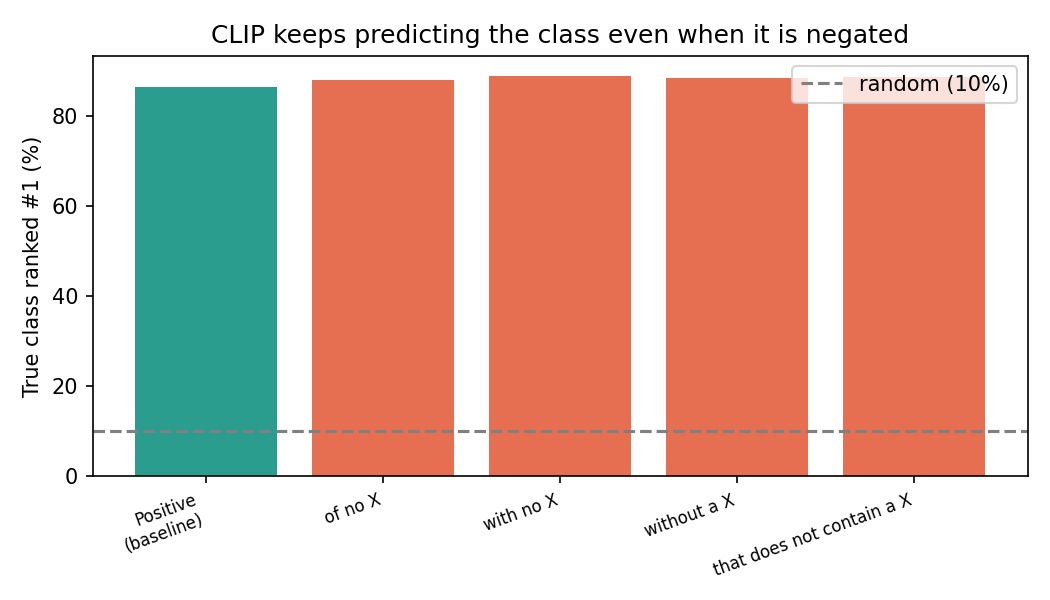

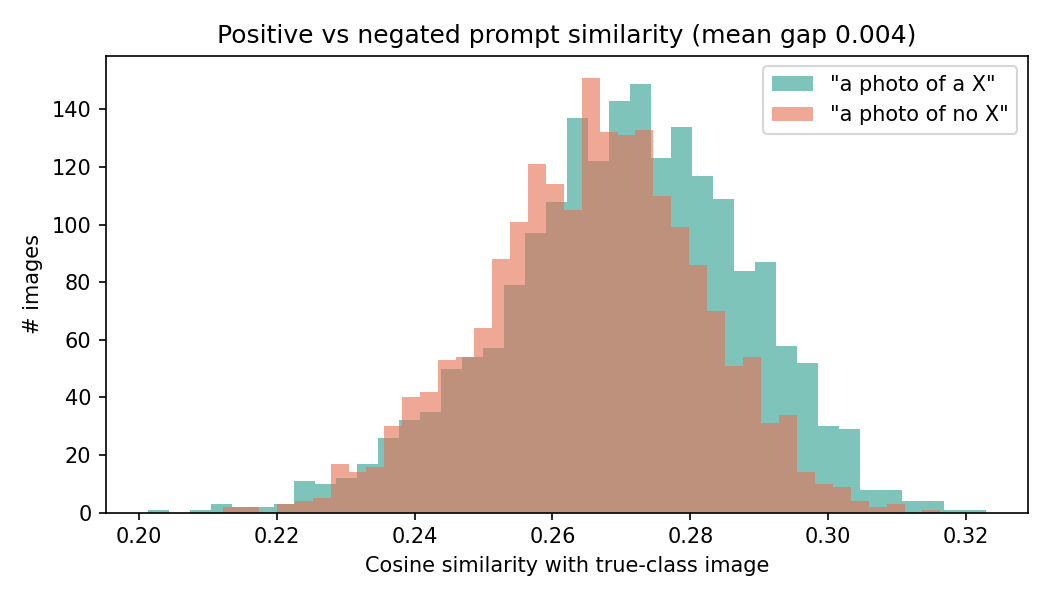

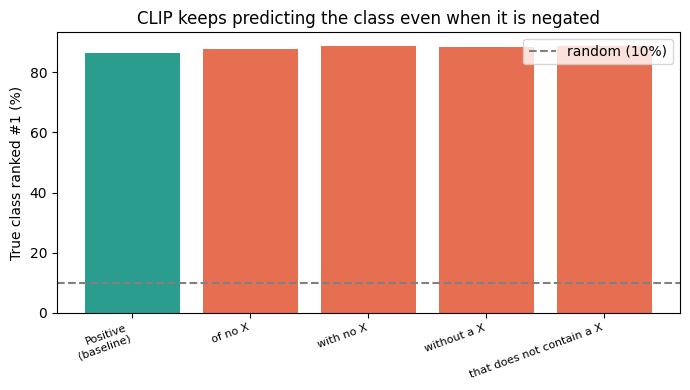

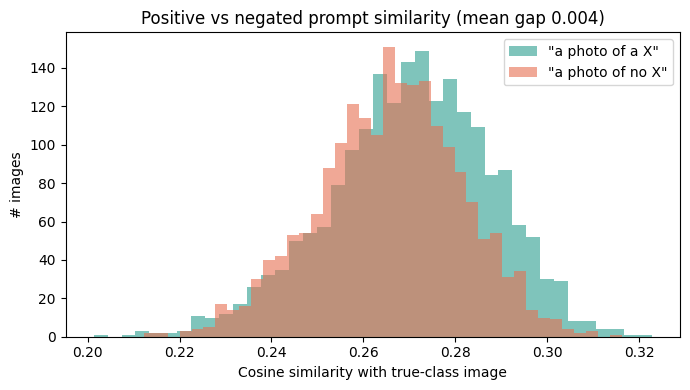

In [7]:
# 5. 실행
N_IMAGES = 2000

print(f"Device: {DEVICE}")
model, preprocess, tokenizer = load_model()
loader, classnames = load_dataset(preprocess, n_images=N_IMAGES)
print(f"클래스: {classnames}")

img_feats, labels = encode_all_images(model, loader)
results = run_experiments(model, tokenizer, img_feats, labels, classnames)
plot_results(results, classnames)

print("\n==== 요약 ====")
print(f"긍정 프롬프트 정확도       : {results['positive_accuracy']*100:.1f}%")
avg_ignored = np.mean(list(results['negation_ignored'].values()))
print(f"부정 프롬프트 평균 무시율   : {avg_ignored*100:.1f}%")
print(f"긍정-부정 유사도 평균 차이  : {results['sim_gap']:.4f}")

from IPython.display import Image, display
display(Image("result_bar.png"))
display(Image("result_simdist.png"))

Device: cuda

=== 모델: ViT-B-32/openai ===


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  [cifar10] baseline  85.7%  |  negation-ignored  87.6%


100%|██████████| 792M/792M [00:47<00:00, 16.8MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.67MB/s]


  [pets  ] baseline  78.2%  |  negation-ignored  71.0%

=== 모델: ViT-L-14/openai ===


...

  [cifar10] baseline  92.3%  |  negation-ignored  87.9%


  [pets  ] baseline  89.7%  |  negation-ignored  82.9%

=== 모델: ViT-B-32/laion2b ===


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  [cifar10] baseline  94.1%  |  negation-ignored  93.2%


  [pets  ] baseline  88.3%  |  negation-ignored  83.9%
saved: level1_heatmap_negation.png
saved: level1_heatmap_baseline.png
saved: level1_bars.png

==== 그리드 요약 (negation-ignored %) ====
model \ data   | cifar10 |    pets
ViT-B-32/openai   |    87.6 |    71.0
ViT-L-14/openai   |    87.9 |    82.9
ViT-B-32/laion2b  |    93.2 |    83.9


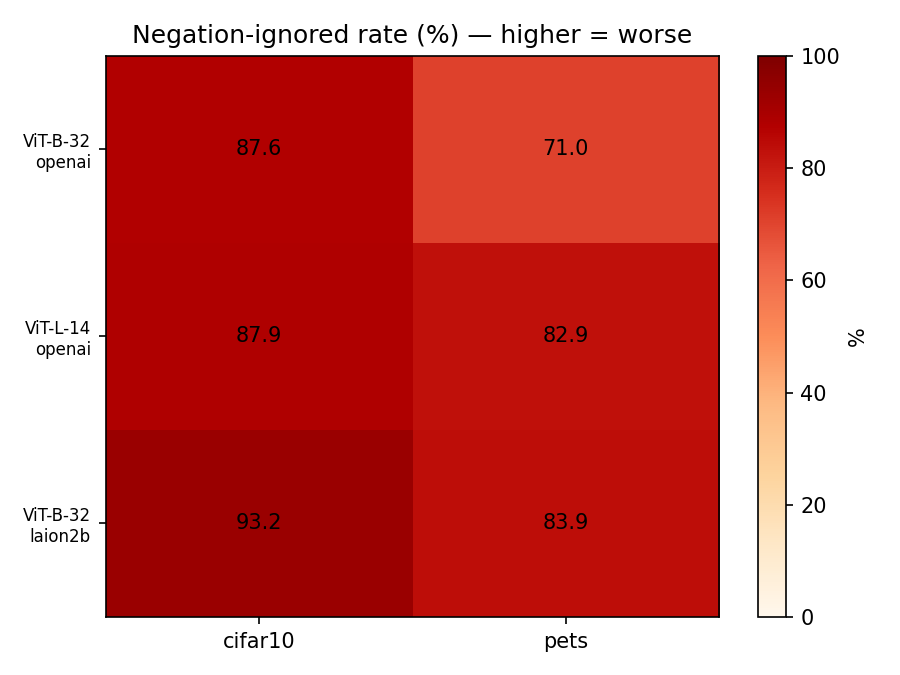

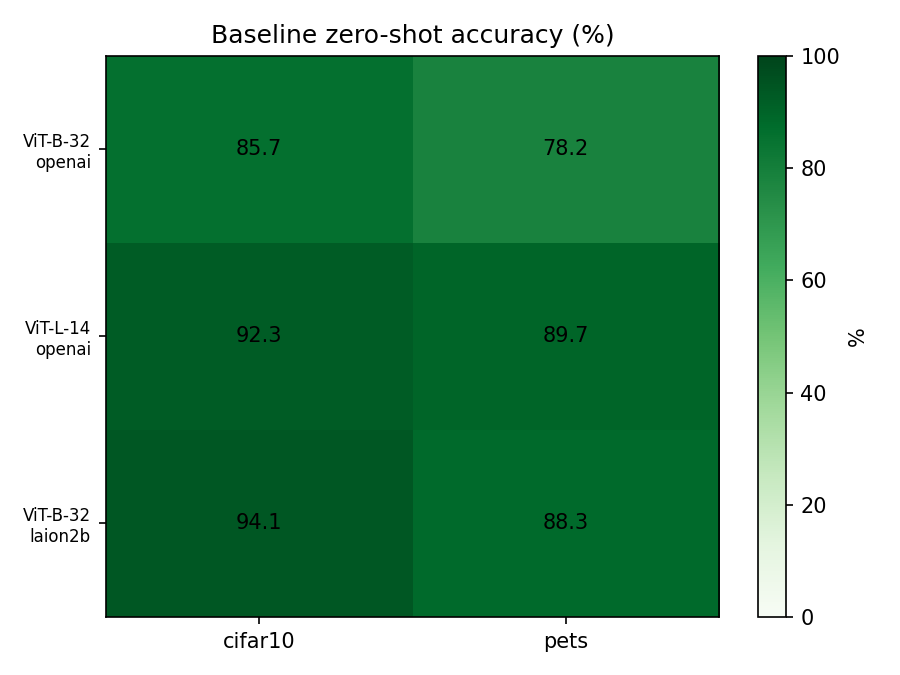

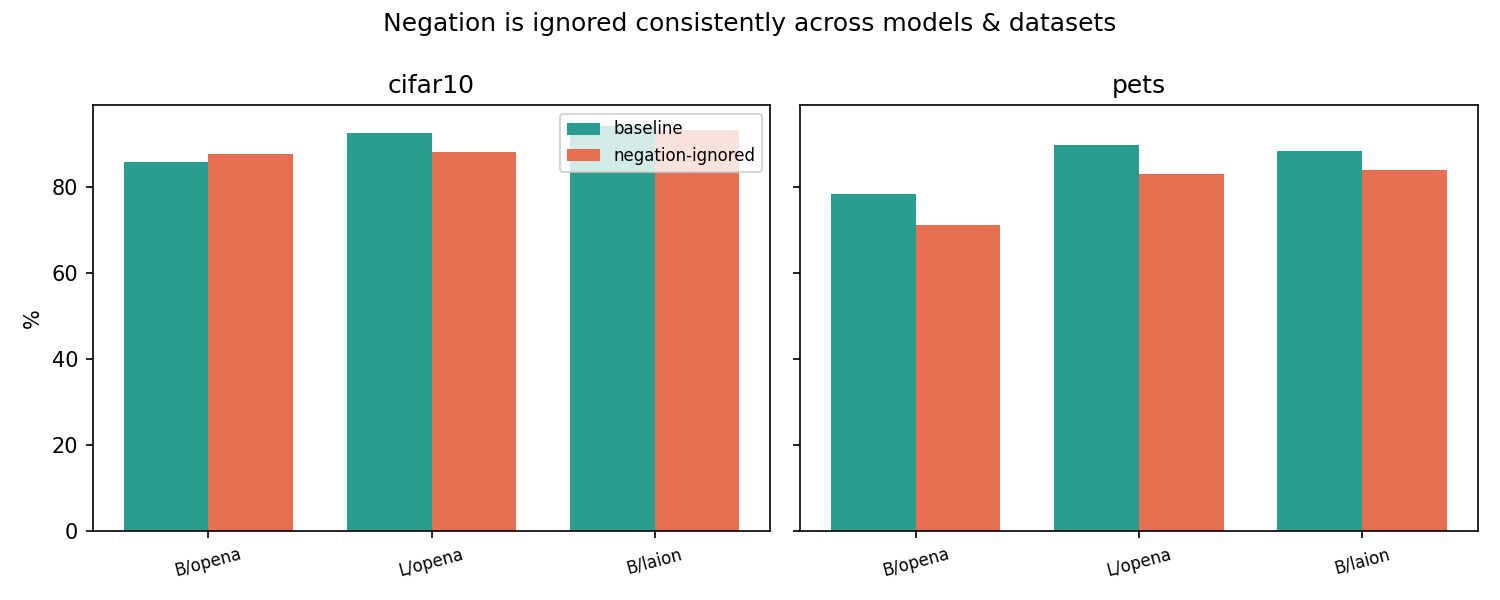

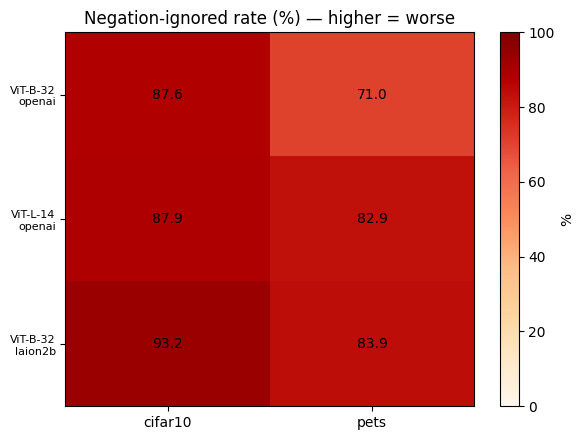

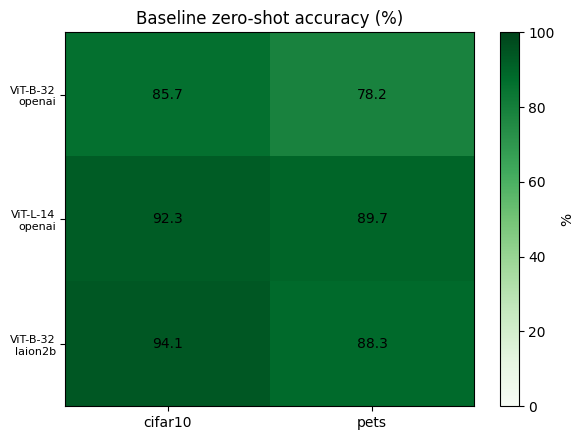

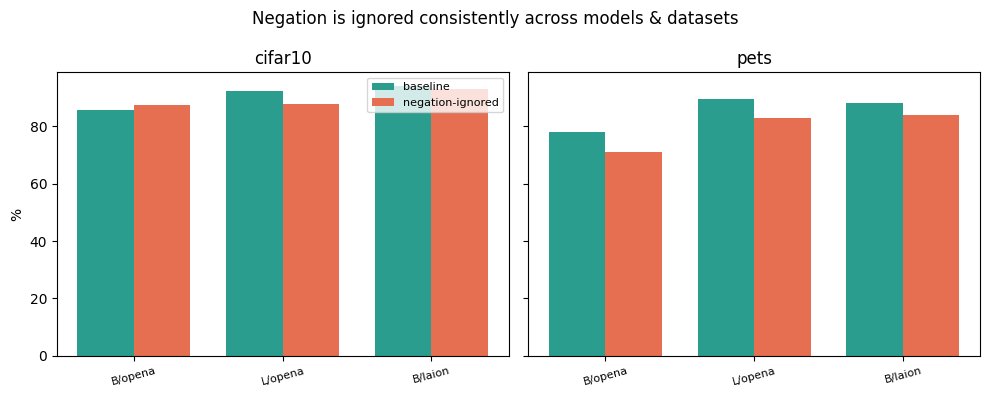

In [8]:
"""
CLIP Negation Weakness — Level 1: Generalization across datasets & models
=========================================================================
"CLIP이 부정을 무시한다"가 특정 데이터셋/모델의 우연이 아님을 보이기 위해
(데이터셋 × 모델) 조합마다 negation-ignored rate를 측정하고 히트맵으로 정리.

데이터셋 : CIFAR-10, Oxford-IIIT Pets
모델     : ViT-B/32 (OpenAI), ViT-L/14 (OpenAI), ViT-B/32 (LAION-2B)

작성: [한지훈]
"""

import numpy as np
import torch
import open_clip
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

POS_TEMPLATE = "a photo of a {}"
NEG_TEMPLATES = [
    "a photo of no {}",
    "a photo with no {}",
    "a photo without a {}",
    "a photo that does not contain a {}",
]

MODELS = [
    ("ViT-B-32", "openai"),
    ("ViT-L-14", "openai"),
    ("ViT-B-32", "laion2b_s34b_b79k"),
]
DATASETS = ["cifar10", "pets"]


# 모델 / 데이터
def load_model(model_name, pretrained):
    model, _, preprocess = open_clip.create_model_and_transforms(
        model_name, pretrained=pretrained
    )
    tokenizer = open_clip.get_tokenizer(model_name)
    model = model.to(DEVICE).eval()
    return model, preprocess, tokenizer


def _clean(names):
    return [n.replace("_", " ").lower() for n in names]


def load_dataset(name, preprocess, n_images=1500):
    if name == "cifar10":
        ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=preprocess)
        classnames = _clean(ds.classes)
    elif name == "pets":
        ds = datasets.OxfordIIITPet(root="./data", split="test",
                                    download=True, transform=preprocess)
        classnames = _clean(ds.classes)
    else:
        raise ValueError(name)

    if n_images and n_images < len(ds):
        idxs = np.linspace(0, len(ds) - 1, n_images).astype(int).tolist()
        ds = Subset(ds, idxs)
    loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=0)
    return loader, classnames


# 인코딩 / 분류
@torch.no_grad()
def encode_texts(model, tokenizer, prompts):
    tokens = tokenizer(prompts).to(DEVICE)
    feats = model.encode_text(tokens)
    return feats / feats.norm(dim=-1, keepdim=True)


@torch.no_grad()
def encode_all_images(model, loader, desc=""):
    img_feats, labels = [], []
    for images, lbls in tqdm(loader, desc=f"인코딩 {desc}", leave=False):
        images = images.to(DEVICE)
        feats = model.encode_image(images)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        img_feats.append(feats.cpu())
        labels.append(lbls)
    return torch.cat(img_feats), torch.cat(labels)


@torch.no_grad()
def classify(img_feats, text_feats):
    logits = img_feats.to(DEVICE) @ text_feats.T
    return logits.argmax(dim=1).cpu()


def measure(model, tokenizer, img_feats, labels, classnames):
    """baseline 정확도 + 부정 템플릿 평균 무시율 반환."""
    pos_text = encode_texts(model, tokenizer,
                            [POS_TEMPLATE.format(c) for c in classnames])
    pos_acc = (classify(img_feats, pos_text) == labels).float().mean().item()

    ignored = []
    for tmpl in NEG_TEMPLATES:
        neg_text = encode_texts(model, tokenizer,
                                [tmpl.format(c) for c in classnames])
        ignored.append((classify(img_feats, neg_text) == labels).float().mean().item())
    return pos_acc, float(np.mean(ignored))


# 그리드 실행
def run_grid(n_images=1500):
    pos_grid = np.zeros((len(MODELS), len(DATASETS)))
    neg_grid = np.zeros((len(MODELS), len(DATASETS)))

    for mi, (model_name, pretrained) in enumerate(MODELS):
        tag = f"{model_name}/{pretrained.split('_')[0]}"
        print(f"\n=== 모델: {tag} ===")
        model, preprocess, tokenizer = load_model(model_name, pretrained)

        for di, dname in enumerate(DATASETS):
            loader, classnames = load_dataset(dname, preprocess, n_images)
            img_feats, labels = encode_all_images(model, loader, desc=dname)
            pos_acc, neg_ignored = measure(model, tokenizer, img_feats, labels, classnames)
            pos_grid[mi, di] = pos_acc * 100
            neg_grid[mi, di] = neg_ignored * 100
            print(f"  [{dname:6s}] baseline {pos_acc*100:5.1f}%  |  "
                  f"negation-ignored {neg_ignored*100:5.1f}%")

        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    return pos_grid, neg_grid


# 시각화
def plot_heatmap(grid, title, fname, cmap="OrRd"):
    model_labels = [f"{m}\n{p.split('_')[0]}" for m, p in MODELS]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels(DATASETS)
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(model_labels, fontsize=8)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid[i, j]:.1f}", ha="center", va="center",
                    color="black", fontsize=10)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="%")
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    print(f"saved: {fname}")


def plot_paired_bars(pos_grid, neg_grid, fname="level1_bars.png"):
    #데이터셋별로 baseline vs negation-ignored 묶어서 비교.
    model_labels = [f"{m.split('-')[1]}/{p.split('_')[0][:5]}" for m, p in MODELS]
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(10, 4), sharey=True)
    x = np.arange(len(MODELS))
    w = 0.38
    for di, dname in enumerate(DATASETS):
        ax = axes[di]
        ax.bar(x - w/2, pos_grid[:, di], w, label="baseline", color="#2a9d8f")
        ax.bar(x + w/2, neg_grid[:, di], w, label="negation-ignored", color="#e76f51")
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, fontsize=8, rotation=15)
        ax.set_title(dname)
        ax.axhline(0, color="k", lw=0.5)
        if di == 0:
            ax.set_ylabel("%")
            ax.legend(fontsize=8)
    plt.suptitle("Negation is ignored consistently across models & datasets")
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    print(f"saved: {fname}")


# 실행
if __name__ == "__main__" or True:
    print("Device:", DEVICE)
    N_IMAGES = 1500

    pos_grid, neg_grid = run_grid(n_images=N_IMAGES)

    plot_heatmap(neg_grid, "Negation-ignored rate (%) — higher = worse",
                 "level1_heatmap_negation.png")
    plot_heatmap(pos_grid, "Baseline zero-shot accuracy (%)",
                 "level1_heatmap_baseline.png", cmap="Greens")
    plot_paired_bars(pos_grid, neg_grid)

    print("\n==== 그리드 요약 (negation-ignored %) ====")
    header = "model \\ data   | " + " | ".join(f"{d:>7s}" for d in DATASETS)
    print(header)
    for mi, (m, p) in enumerate(MODELS):
        row = " | ".join(f"{neg_grid[mi, di]:7.1f}" for di in range(len(DATASETS)))
        print(f"{m}/{p.split('_')[0]:8s} | {row}")

    try:
        from IPython.display import Image, display
        for f in ["level1_heatmap_negation.png", "level1_heatmap_baseline.png", "level1_bars.png"]:
            display(Image(f))
    except Exception:
        pass